# Video 5 - Virtual Screening with QSAR
**AI for Drug Discovery series**
Author: Sreenivas Bhattiprolu (DigitalSreeni)
YouTube: [youtube.com/@DigitalSreeni](https://www.youtube.com/@DigitalSreeni)
GitHub: [github.com/bnsreenu](https://github.com/bnsreenu)

---

## What this notebook covers

We use the XGBoost QSAR model trained in Video 4b to screen a library of
kinase-focused compounds from ChEMBL and identify predicted EGFR inhibitors.

**Steps:**
1. Load the trained XGBoost model and verify it works
2. Build a screening library from four other kinase targets in ChEMBL
3. Deduplicate the library against the EGFR training data
4. Apply Lipinski Rule of Five drug-likeness filter
5. Compute features using the same pipeline as Video 4a
6. Score every compound with XGBoost - get predicted log IC50
7. Compare naive top-20 vs MaxMin diversity-selected top-20
8. UMAP chemical space visualization
9. Draw the top predicted hits as 2D structures

**Run notebook 4b first** - this notebook loads the saved XGBoost model
and feature names from Video 4b's output directory.

## 1. Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Install and import libraries

In [ ]:
!pip install rdkit chembl-webresource-client umap-learn xgboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.1/37.1 MB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.5 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')
import os
import pickle

from rdkit import Chem, DataStructs
from rdkit.Chem import Draw, Descriptors, rdMolDescriptors
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem.Scaffolds import MurckoScaffold
from IPython.display import display

import xgboost as xgb
from sklearn.preprocessing import StandardScaler
import umap

from chembl_webresource_client.new_client import new_client

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'figure.dpi':        120,
})
print('All libraries imported.')

All libraries imported.


## 3. Set paths

In [ ]:
MODEL_DIR = ('/content/drive/MyDrive/ColabNotebooks/AI_for_drug_discovery/Video4_qsar_modeling/data/')
OUTPUT_DIR = ('/content/drive/MyDrive/ColabNotebooks/AI_for_drug_discovery/Video4_qsar_modeling/data/')

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Model directory: {MODEL_DIR}')
print(f'Output directory: {OUTPUT_DIR}')

Model directory: /content/drive/MyDrive/ColabNotebooks/AI_for_drug_discovery/Video4_qsar_modeling/data/
Output directory: /content/drive/MyDrive/ColabNotebooks/AI_for_drug_discovery/Video4_qsar_modeling/data/


## 4. Load the trained XGBoost model

We load the model saved at the end of Video 4b. Before using it for
screening, we verify it predicts correctly on a few well-known EGFR
inhibitors. This is a sanity check -- if the predictions are wildly
off on erlotinib and gefitinib, something went wrong with the save/load.

Erlotinib has a measured EGFR IC50 of around 2 nM (log IC50 ~ 0.3).
Gefitinib has a measured IC50 of around 33 nM (log IC50 ~ 1.5).
We expect the model to predict low log IC50 (potent) for both.

In [ ]:
# Load model and feature names
xgb_reg = xgb.XGBRegressor()
xgb_reg.load_model(MODEL_DIR + 'xgb_reg_model.json')

xgb_cls = xgb.XGBClassifier()
xgb_cls.load_model(MODEL_DIR + 'xgb_cls_model.json')

feature_names = pd.read_csv(
    MODEL_DIR + 'feature_names.csv', header=None)[0].tolist()

print(f'Regression model loaded.')
print(f'Classification model loaded.')
print(f'Feature names: {len(feature_names)} features')
print(f'  First 8: {feature_names[:8]}')
print(f'  Then {len(feature_names)-8} fingerprint bits')

Regression model loaded.
Classification model loaded.
Feature names: 1032 features
  First 8: ['MW', 'LogP', 'HBD', 'HBA', 'RotB', 'TPSA', 'Rings', 'ArRings']
  Then 1024 fingerprint bits


In [ ]:
# Helper functions -- must match Video 4a exactly
DESC_COLS = ['MW', 'LogP', 'HBD', 'HBA', 'RotB', 'TPSA', 'Rings', 'ArRings']

def compute_descriptors(mol):
    return {
        'MW':      round(Descriptors.MolWt(mol), 2),
        'LogP':    round(Descriptors.MolLogP(mol), 2),
        'HBD':     rdMolDescriptors.CalcNumHBD(mol),
        'HBA':     rdMolDescriptors.CalcNumHBA(mol),
        'RotB':    rdMolDescriptors.CalcNumRotatableBonds(mol),
        'TPSA':    round(rdMolDescriptors.CalcTPSA(mol), 2),
        'Rings':   rdMolDescriptors.CalcNumRings(mol),
        'ArRings': rdMolDescriptors.CalcNumAromaticRings(mol),
    }

def morgan_fp(mol, radius=2, n_bits=1024):
    gen = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=n_bits)
    fp  = gen.GetFingerprint(mol)
    arr = np.zeros(n_bits, dtype=np.uint8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

def mol_to_features(mol):
    """Convert a molecule to a 1032-element feature vector.
    Layout: 8 descriptors + 1024 fingerprint bits (matches Video 4a exactly).
    """
    desc = compute_descriptors(mol)
    fp   = morgan_fp(mol)
    desc_arr = np.array([desc[c] for c in DESC_COLS], dtype=np.float32)
    return np.hstack([desc_arr, fp]).astype(np.float32)

print('Feature functions defined.')

Feature functions defined.


In [ ]:
# Sanity check on known EGFR inhibitors
known_egfr = [
    ('Erlotinib',  'C#Cc1cccc(Nc2ncnc3cc(OCCOC)c(OCCOC)cc23)c1',  0.30),
    ('Gefitinib',  'COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCOCC1', 1.52),
    ('Afatinib',   'CN(C)/C=C/C(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1OCC', 0.60),
    ('Osimertinib','C=CC(=O)Nc1cc(Nc2nccc(-c3cn(C)c4ccccc34)n2)c(OC)cc1N(C)CCN(C)C', -0.22),
]

print('Sanity check -- predictions on known EGFR inhibitors:')
print(f'{"Compound":15s}  {"True log IC50":14s}  {"Pred log IC50":14s}  {"Pred IC50 (nM)":14s}  {"Active prob":12s}')
print('-' * 75)

for name, smi, true_log_ic50 in known_egfr:
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        print(f'{name}: invalid SMILES')
        continue
    X = mol_to_features(mol).reshape(1, -1)
    pred_log  = xgb_reg.predict(X)[0]
    pred_prob = xgb_cls.predict_proba(X)[0][1]
    pred_nM   = 10 ** pred_log
    print(f'{name:15s}  {true_log_ic50:14.2f}  {pred_log:14.2f}  {pred_nM:14.1f}  {pred_prob:12.3f}')

print()
print('Predictions should show low log IC50 (potent) for all four compounds.')

Sanity check -- predictions on known EGFR inhibitors:
Compound         True log IC50   Pred log IC50   Pred IC50 (nM)  Active prob 
---------------------------------------------------------------------------
Erlotinib                  0.30            1.30            19.9         0.933
Gefitinib                  1.52            1.48            30.0         0.960
Afatinib                   0.60            0.71             5.1         0.940
Osimertinib               -0.22            1.99            97.1         0.800

Predictions should show low log IC50 (potent) for all four compounds.


## 5. Build the screening library

We pull compounds from four kinase targets that are not EGFR. Kinase
inhibitors are structurally relevant -- they share scaffolds and binding
motifs common to EGFR inhibitors, making this a realistic and challenging
screening library.

Source targets:
- VEGFR2 (CHEMBL279) -- angiogenesis target, many clinical inhibitors
- BRAF (CHEMBL5145) -- melanoma target, diverse heterocyclic scaffolds
- ABL1 (CHEMBL1862) -- leukemia target, shares kinase inhibitor chemistry
- CDK2 (CHEMBL301) -- cell cycle kinase, broad compound collection

We cache the raw pull to CSV so we never need to wait for the network request again.

In [ ]:
RAW_LIB_CSV = OUTPUT_DIR + 'screening_library_raw.csv'

if os.path.exists(RAW_LIB_CSV):
    print('Loading cached screening library...')
    df_lib_raw = pd.read_csv(RAW_LIB_CSV)
    print(f'Loaded {len(df_lib_raw)} records.')
else:
    print('Querying ChEMBL for screening library compounds...')
    activity = new_client.activity

    source_targets = [
        ('VEGFR2', 'CHEMBL279'),
        ('BRAF',   'CHEMBL5145'),
        ('ABL1',   'CHEMBL1862'),
        ('CDK2',   'CHEMBL301'),
    ]

    all_records = []
    for target_name, target_id in source_targets:
        print(f'  Pulling {target_name} ({target_id})...')
        records = list(activity.filter(
            target_chembl_id         = target_id,
            standard_type            = 'IC50',
            standard_units           = 'nM',
            assay_confidence_score   = 9,
            pchembl_value__isnull    = False,
            canonical_smiles__isnull = False,
        ).only(['molecule_chembl_id', 'canonical_smiles'])[:2000])
        for r in records:
            r['source_target'] = target_name
        all_records.extend(records)
        print(f'    {len(records)} records retrieved')

    df_lib_raw = pd.DataFrame(all_records)
    df_lib_raw.to_csv(RAW_LIB_CSV, index=False)
    print(f'Total: {len(df_lib_raw)} records saved to cache.')

print(f'Unique compounds before deduplication: {df_lib_raw["molecule_chembl_id"].nunique()}')
df_lib_raw.head()

Loading cached screening library...
Loaded 8000 records.
Unique compounds before deduplication: 5728


,canonical_smiles,molecule_chembl_id,source_target
0,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,CHEMBL68920,VEGFR2
1,Nc1ncnc2c1c(-c1cccc(Oc3ccccc3)c1)cn2C1CCCC1,CHEMBL69638,VEGFR2
2,c1ccc(-c2cnc(Nc3ccccn3)o2)cc1,CHEMBL419526,VEGFR2
3,Cc1cc(C(=O)NCCN2CCOCC2)[nH]c1/C=C1\C(=O)N(C)c2...,CHEMBL443268,VEGFR2
4,Cc1ccc(Nc2ncc(-c3ccccc3)s2)nc1,CHEMBL330621,VEGFR2


## 6. Deduplicate and clean the library

Three deduplication steps:
1. Remove duplicate SMILES within the library itself
2. Remove any compound already in our EGFR training or test sets
3. Validate all SMILES strings

Step 2 is critical -- any compound the QSAR model was trained on cannot
be a genuine novel prediction. We load the EGFR compound IDs from Video 4
to identify and remove these.

In [ ]:
# Step 1: one row per unique compound
df_lib = df_lib_raw.drop_duplicates(subset='molecule_chembl_id').copy()
print(f'After removing library duplicates: {len(df_lib)} compounds')

# Step 2: remove any compound tested on EGFR
y_train = pd.read_csv(MODEL_DIR + 'y_train.csv')
y_test  = pd.read_csv(MODEL_DIR + 'y_test.csv')
egfr_ids = set(y_train['molecule_chembl_id']) | set(y_test['molecule_chembl_id'])

df_lib = df_lib[~df_lib['molecule_chembl_id'].isin(egfr_ids)].copy()
print(f'After removing EGFR-tested compounds: {len(df_lib)} compounds')

# Step 3: validate SMILES
df_lib['mol'] = df_lib['canonical_smiles'].apply(Chem.MolFromSmiles)
df_lib = df_lib[df_lib['mol'].notna()].copy()
print(f'After removing invalid SMILES: {len(df_lib)} compounds')
print()
print('Source target breakdown:')
print(df_lib['source_target'].value_counts())

After removing library duplicates: 5728 compounds
After removing EGFR-tested compounds: 5334 compounds
After removing invalid SMILES: 5334 compounds

Source target breakdown:
source_target
CDK2      1515
VEGFR2    1416
BRAF      1375
ABL1      1028
Name: count, dtype: int64


## 7. Apply Lipinski Rule of Five filter

Before scoring, we remove compounds that violate more than one Lipinski
rule. These compounds are unlikely to be orally bioavailable regardless
of how well the model predicts their EGFR IC50.

Filtering before scoring reduces noise and saves compute. There is no
point predicting IC50 for a compound that would fail in clinical development
due to poor absorption.

In [ ]:
def lipinski_passes(mol, max_violations=1):
    """Return True if the compound violates at most max_violations Ro5 rules."""
    mw   = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd  = rdMolDescriptors.CalcNumHBD(mol)
    hba  = rdMolDescriptors.CalcNumHBA(mol)

    violations = sum([
        mw   > 500,
        logp > 5,
        hbd  > 5,
        hba  > 10,
    ])
    return violations <= max_violations


n_before = len(df_lib)
df_lib['ro5_pass'] = df_lib['mol'].apply(lipinski_passes)
df_lib = df_lib[df_lib['ro5_pass']].copy()
print(f'Before Lipinski filter: {n_before}')
print(f'After Lipinski filter:  {len(df_lib)}')
print(f'Removed: {n_before - len(df_lib)} compounds ({100*(n_before-len(df_lib))/n_before:.1f}%)')

Before Lipinski filter: 5334
After Lipinski filter:  4741
Removed: 593 compounds (11.1%)


## 8. Compute features for the screening library

We compute the exact same features as Video 4a:
- 8 physicochemical descriptors (MW, LogP, HBD, HBA, RotB, TPSA, Rings, ArRings)
- 1024-bit Morgan fingerprint (ECFP4, radius=2)

The feature layout must match exactly what the XGBoost model was trained on.
Any mismatch will produce garbage predictions.

In [ ]:
print('Computing features for screening library...')
X_lib = np.vstack([mol_to_features(mol) for mol in df_lib['mol']])
print(f'Feature matrix: {X_lib.shape}')
print(f'  ({X_lib.shape[0]} compounds x {X_lib.shape[1]} features)')
print(f'  Expected: {len(feature_names)} features -- match: {X_lib.shape[1] == len(feature_names)}')

Computing features for screening library...
Feature matrix: (4741, 1032)
  (4741 compounds x 1032 features)
  Expected: 1032 features -- match: True


## 9. Score the library with XGBoost

Every compound in the library gets two predictions:
- Predicted log10(IC50) from the regression model
- Probability of being active (IC50 <= 1000 nM) from the classifier

We then convert log10(IC50) back to nM for interpretability.

In [ ]:
print('Scoring screening library...')
pred_log_ic50 = xgb_reg.predict(X_lib)
pred_proba    = xgb_cls.predict_proba(X_lib)[:, 1]
pred_ic50_nM  = 10 ** pred_log_ic50

df_lib = df_lib.copy()
df_lib['pred_log_ic50'] = pred_log_ic50
df_lib['pred_ic50_nM']  = pred_ic50_nM
df_lib['pred_active_prob'] = pred_proba

print(f'Scoring complete. {len(df_lib)} compounds scored.')
print()
print('Predicted IC50 distribution:')
print(f'  Min predicted IC50:    {pred_ic50_nM.min():.2f} nM')
print(f'  Median predicted IC50: {np.median(pred_ic50_nM):.0f} nM')
print(f'  Max predicted IC50:    {pred_ic50_nM.max():.0f} nM')
print()
print(f'Predicted actives (IC50 <= 1000 nM): {(pred_ic50_nM <= 1000).sum()} compounds')
print(f'  ({100*(pred_ic50_nM <= 1000).mean():.1f}% of library)')

Scoring screening library...
Scoring complete. 4741 compounds scored.

Predicted IC50 distribution:
  Min predicted IC50:    15.82 nM
  Median predicted IC50: 1481 nM
  Max predicted IC50:    59264 nM

Predicted actives (IC50 <= 1000 nM): 1767 compounds
  (37.3% of library)


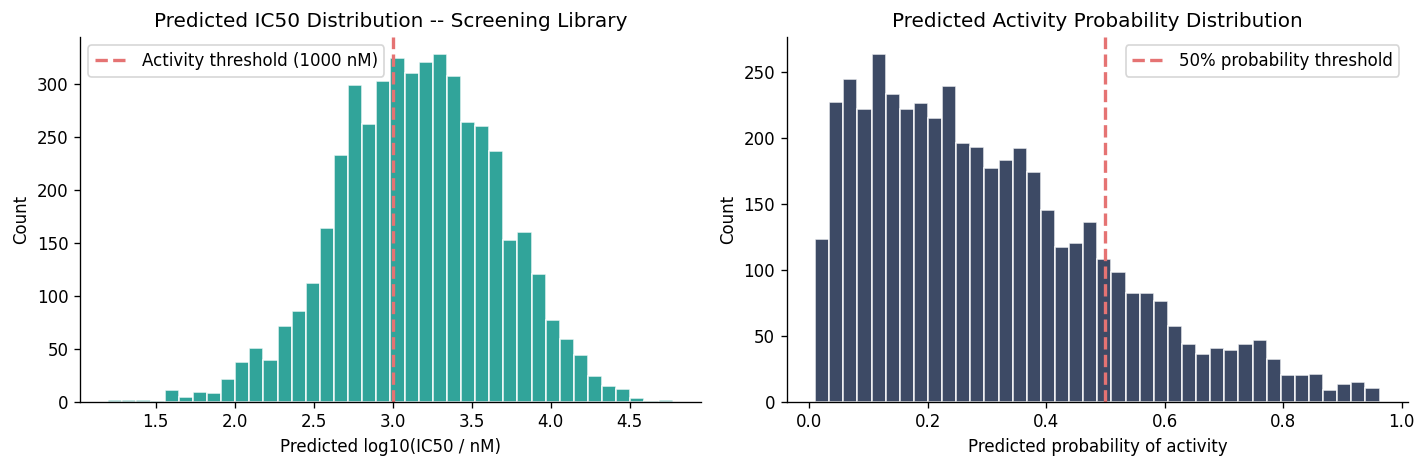

In [ ]:
# Visualize predicted IC50 distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(pred_log_ic50, bins=40, color='#0D9488', alpha=0.85, edgecolor='white')
axes[0].axvline(np.log10(1000), color='#E57373', lw=2, ls='--',
                label='Activity threshold (1000 nM)')
axes[0].set(xlabel='Predicted log10(IC50 / nM)', ylabel='Count',
            title='Predicted IC50 Distribution -- Screening Library')
axes[0].legend()

axes[1].hist(pred_proba, bins=40, color='#1B2A4A', alpha=0.85, edgecolor='white')
axes[1].axvline(0.5, color='#E57373', lw=2, ls='--', label='50% probability threshold')
axes[1].set(xlabel='Predicted probability of activity', ylabel='Count',
            title='Predicted Activity Probability Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

## 10. Naive top-20 vs MaxMin diversity selection

**Naive top-20:** just take the 20 compounds with the lowest predicted IC50.
As discussed in the slides, these are often near-identical analogs of the
same dominant scaffold.

**MaxMin diversity selection:** iteratively pick the compound that is most
different from all already-selected compounds, weighted by predicted potency.
This produces a set that covers multiple scaffold families while still
prioritizing predicted potency.

In [ ]:
# First filter to predicted actives only
df_actives = df_lib[df_lib['pred_ic50_nM'] <= 1000].copy()
df_actives = df_actives.sort_values('pred_log_ic50').reset_index(drop=True)
print(f'Predicted actives pool: {len(df_actives)} compounds')

# Naive top-20
df_top20_naive = df_actives.head(20).copy()
print(f'Naive top-20 selected.')

# Compute fingerprint objects for all actives (needed for Tanimoto)
def get_fp_object(mol):
    gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)
    return gen.GetFingerprint(mol)

fps_actives = [get_fp_object(mol) for mol in df_actives['mol']]


def maxmin_selection(df, fps, n_select=20, sim_threshold=0.4):
    selected = [0]

    for _ in range(n_select - 1):
        remaining = [i for i in range(len(df)) if i not in selected]
        if not remaining:
            break

        min_sims = []
        valid_remaining = []
        for i in remaining:
            sims = DataStructs.BulkTanimotoSimilarity(
                fps[i], [fps[j] for j in selected]
            )
            max_sim = max(sims)
            # Skip compounds too similar to any already selected
            if max_sim <= sim_threshold:
                min_sims.append(min(sims))
                valid_remaining.append(i)

        if not valid_remaining:
            # Fallback: relax threshold if no compounds pass
            valid_remaining = remaining
            min_sims = []
            for i in remaining:
                sims = DataStructs.BulkTanimotoSimilarity(
                    fps[i], [fps[j] for j in selected]
                )
                min_sims.append(min(sims))

        best_idx = valid_remaining[np.argmin(min_sims)]
        selected.append(best_idx)

    return selected


selected_idx = maxmin_selection(df_actives, fps_actives, n_select=20)
df_top20_diverse = df_actives.iloc[selected_idx].copy()

print(f'MaxMin diverse top-20 selected.')
print()
print('Comparison:')
print(f'  Naive top-20     -- mean pred IC50: {df_top20_naive["pred_ic50_nM"].mean():.1f} nM')
print(f'  Diverse top-20   -- mean pred IC50: {df_top20_diverse["pred_ic50_nM"].mean():.1f} nM')

Predicted actives pool: 1767 compounds
Naive top-20 selected.
MaxMin diverse top-20 selected.

Comparison:
  Naive top-20     -- mean pred IC50: 35.0 nM
  Diverse top-20   -- mean pred IC50: 531.8 nM


Unique scaffolds in naive top-20:   18 / 20
Unique scaffolds in diverse top-20: 20 / 20

The diverse selection covers more scaffold families.
Each scaffold family represents a different chemical series to explore.


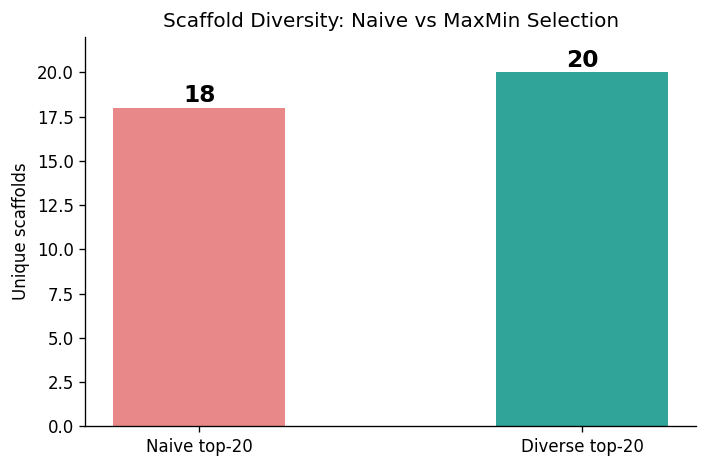

In [ ]:
# Compare scaffold diversity between naive and MaxMin selections
def get_scaffold(mol):
    try:
        scaf = MurckoScaffold.GetScaffoldForMol(mol)
        return Chem.MolToSmiles(scaf)
    except Exception:
        return ''

df_top20_naive['scaffold']   = df_top20_naive['mol'].apply(get_scaffold)
df_top20_diverse['scaffold'] = df_top20_diverse['mol'].apply(get_scaffold)

naive_scaffolds   = df_top20_naive['scaffold'].nunique()
diverse_scaffolds = df_top20_diverse['scaffold'].nunique()

print(f'Unique scaffolds in naive top-20:   {naive_scaffolds} / 20')
print(f'Unique scaffolds in diverse top-20: {diverse_scaffolds} / 20')
print()
print('The diverse selection covers more scaffold families.')
print('Each scaffold family represents a different chemical series to explore.')

# Bar chart comparison
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Naive top-20', 'Diverse top-20'],
              [naive_scaffolds, diverse_scaffolds],
              color=['#E57373', '#0D9488'], alpha=0.85, width=0.45)
ax.set(ylabel='Unique scaffolds', ylim=(0, 22),
       title='Scaffold Diversity: Naive vs MaxMin Selection')
for bar, val in zip(bars, [naive_scaffolds, diverse_scaffolds]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.3,
            str(val), ha='center', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. UMAP chemical space visualization

We project all compounds into 2D space using UMAP on their Morgan
fingerprints. Three groups are shown:
- Known EGFR inhibitors (training set) -- blue
- Screening library -- gray
- MaxMin diverse top-20 hits -- orange stars

Structurally similar compounds will cluster together. The position of
the hits relative to the known EGFR inhibitor clusters tells us how
novel they are and how confident we should be in the predictions.

In [ ]:
print('Computing UMAP embedding...')
print('This may take 30-60 seconds.')

# Load EGFR training compounds for reference
egfr_raw = pd.read_csv(
    '/content/drive/MyDrive/ColabNotebooks/'
    'AI_for_drug_discovery/Video4_qsar_modeling/data/egfr_raw_chembl.csv'
)
egfr_smiles = egfr_raw.drop_duplicates('molecule_chembl_id')[
    ['molecule_chembl_id', 'canonical_smiles']
].copy()
egfr_smiles['mol'] = egfr_smiles['canonical_smiles'].apply(Chem.MolFromSmiles)
egfr_smiles = egfr_smiles[egfr_smiles['mol'].notna()].reset_index(drop=True)
fp_egfr = np.vstack([morgan_fp(mol) for mol in egfr_smiles['mol']])
print(f'EGFR reference compounds: {len(fp_egfr)}')

# Screening library and hits
fp_lib  = np.vstack([morgan_fp(mol) for mol in df_lib['mol']])
fp_hits = np.vstack([morgan_fp(mol) for mol in df_top20_diverse['mol']])

# Combine all three groups for UMAP
fp_all = np.vstack([fp_egfr, fp_lib, fp_hits])

reducer   = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
embedding = reducer.fit_transform(fp_all)

print(f'UMAP complete. Embedding shape: {embedding.shape}')

Computing UMAP embedding...
This may take 30-60 seconds.
EGFR reference compounds: 6306
UMAP complete. Embedding shape: (11067, 2)


## 12. View top predicted hits as 2D structures

We draw the top 20 diverse hits as 2D molecular structures, annotated
with predicted IC50 and activity probability. This is what a medicinal
chemist would receive as the output of the virtual screen -- a shortlist
of compounds to synthesize and test.

Confidence breakdown:
confidence
Low     12
High     8


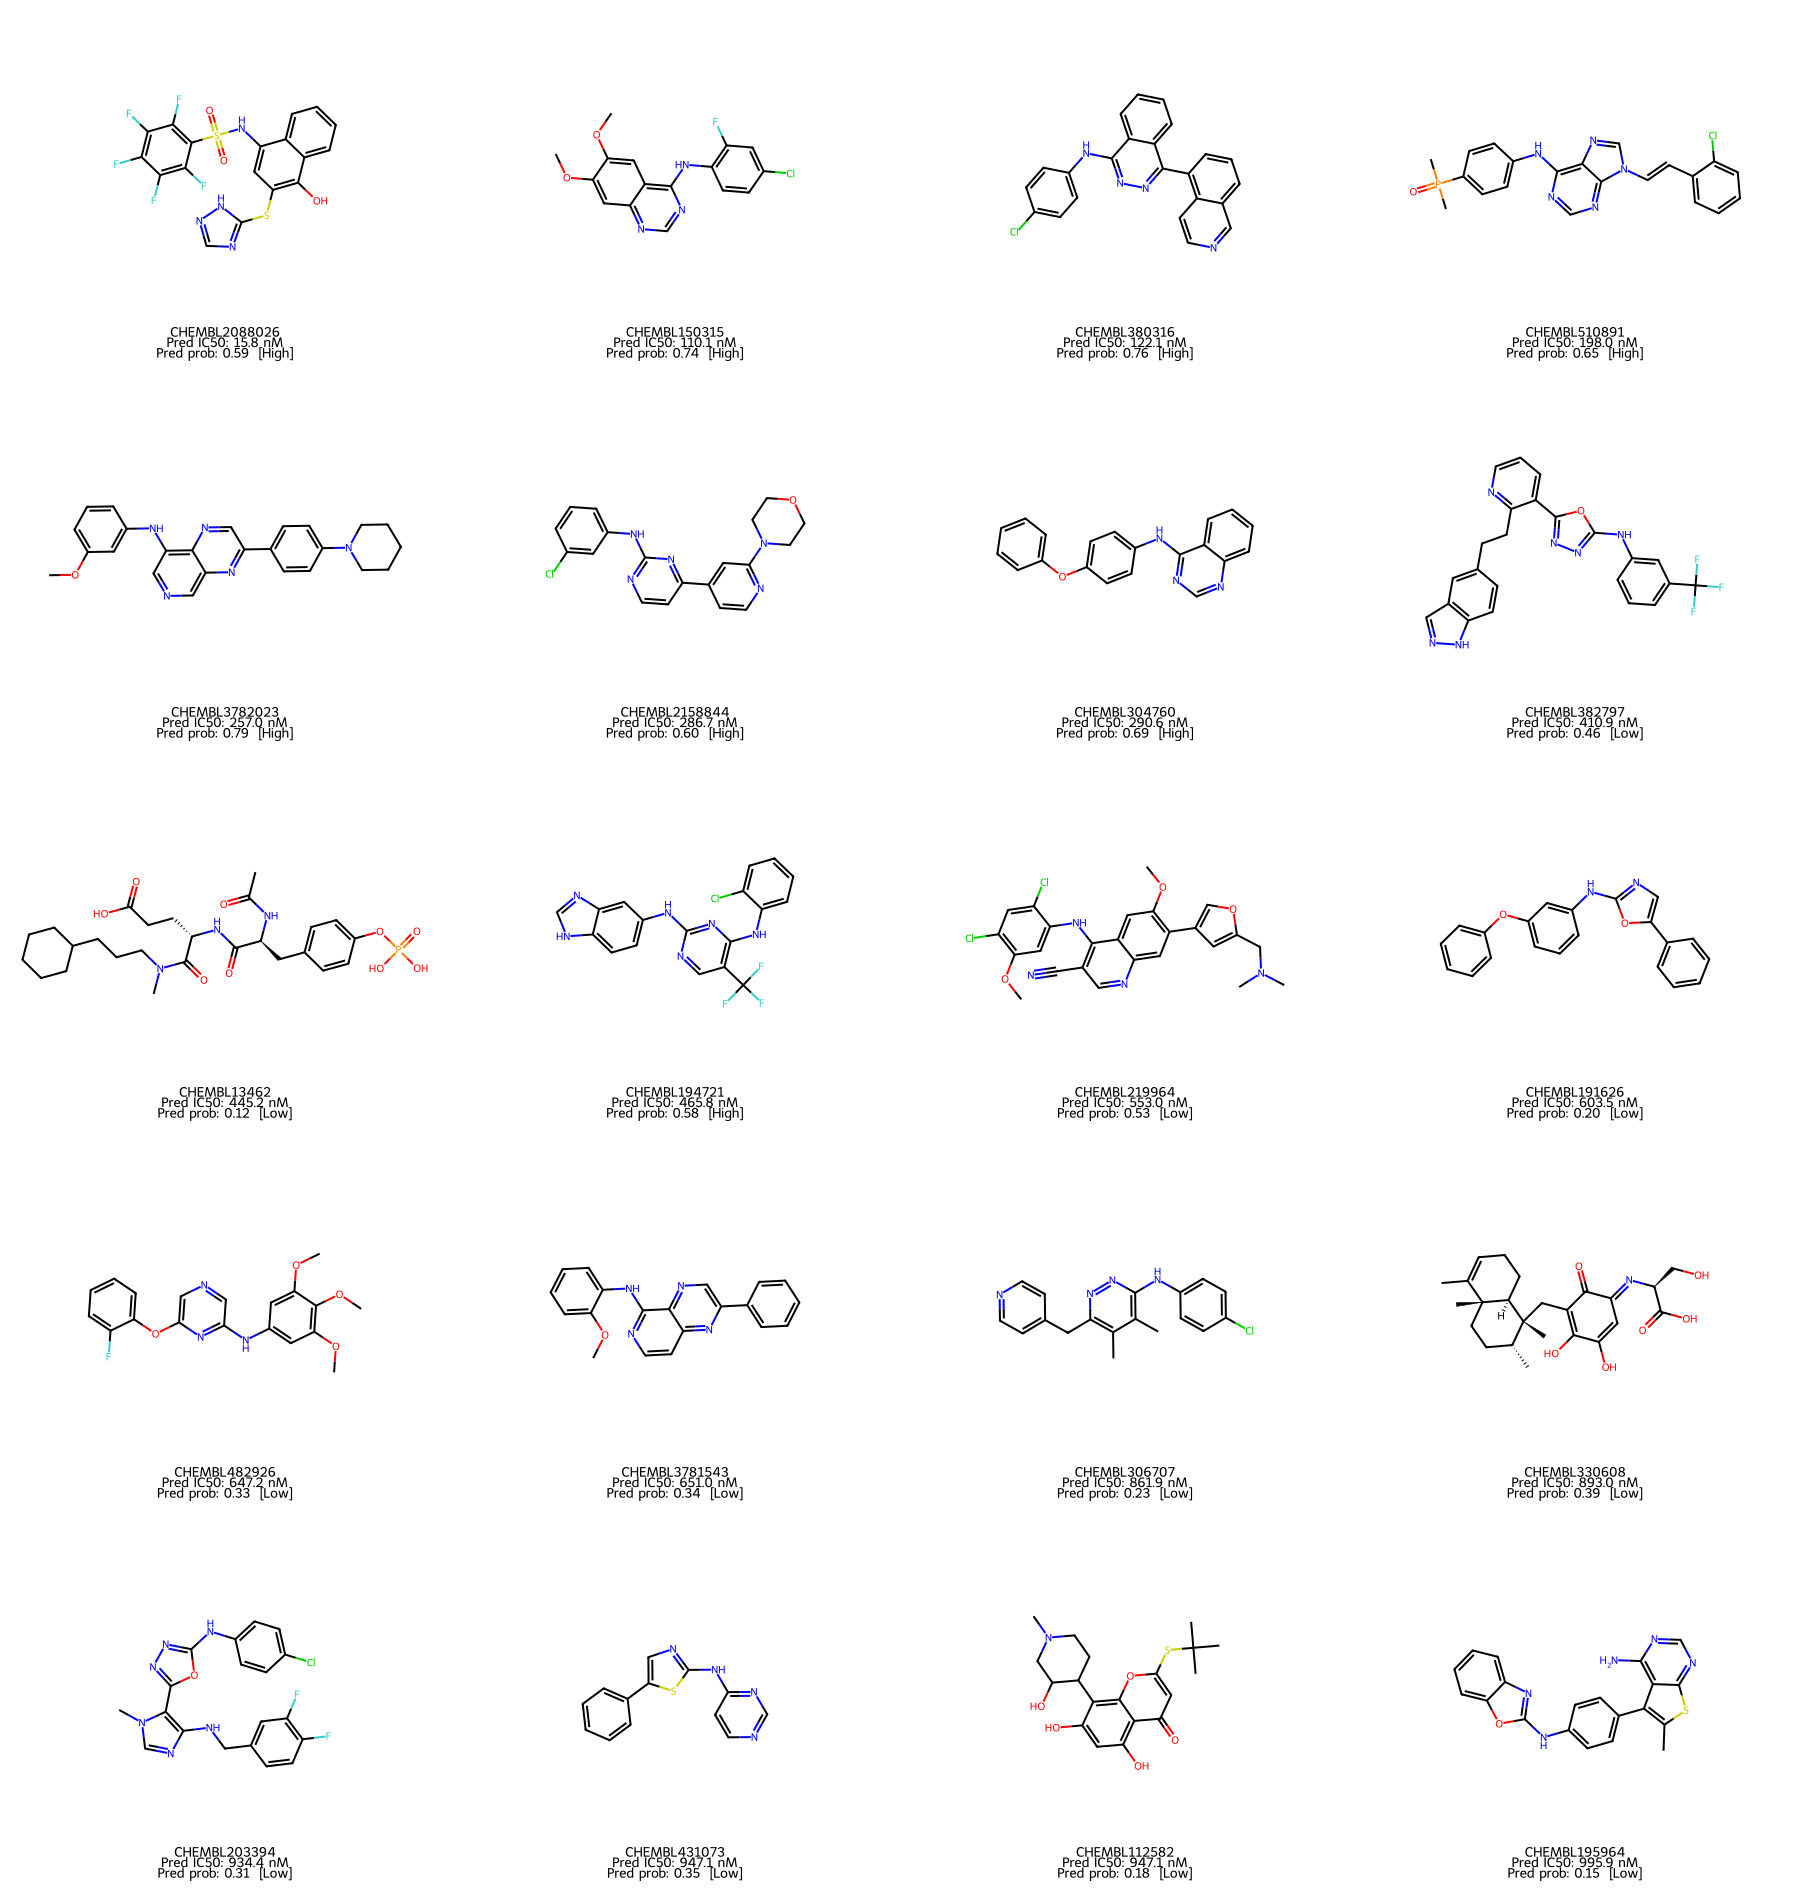


Top 20 diverse predicted hits (sorted by predicted IC50):

molecule_chembl_id source_target  pred_ic50_nM  pred_active_prob
     CHEMBL2088026          BRAF     15.821898          0.589395
      CHEMBL150315        VEGFR2    110.142998          0.739902
      CHEMBL380316        VEGFR2    122.091293          0.762007
      CHEMBL510891          ABL1    198.041641          0.653812
     CHEMBL3782023          ABL1    257.034393          0.791514
     CHEMBL2158844          CDK2    286.730408          0.602306
      CHEMBL304760        VEGFR2    290.610107          0.686527
      CHEMBL382797        VEGFR2    410.860321          0.455042
       CHEMBL13462          ABL1    445.240936          0.123289
      CHEMBL194721          CDK2    465.775513          0.579027
      CHEMBL219964          ABL1    552.974182          0.525985
      CHEMBL191626        VEGFR2    603.500732          0.200055
      CHEMBL482926          BRAF    647.177612          0.332718
     CHEMBL3781543          AB

In [ ]:
# Sort diverse hits by predicted IC50 for display


df_display = df_top20_diverse.sort_values('pred_log_ic50').reset_index(drop=True)

# Confidence flag -- high confidence requires both models to agree
df_display['confidence'] = df_display.apply(
    lambda r: 'High' if r['pred_ic50_nM'] < 500 and r['pred_active_prob'] > 0.5
              else 'Low', axis=1
)

print('Confidence breakdown:')
print(df_display['confidence'].value_counts().to_string())



# Draw grid
mols_to_draw = list(df_display['mol'])
legends = [
    f'{row["molecule_chembl_id"]}\n'
    f'Pred IC50: {row["pred_ic50_nM"]:.1f} nM\n'
    f'Pred prob: {row["pred_active_prob"]:.2f}  [{row["confidence"]}]'
    for _, row in df_display.iterrows()
]

img = Draw.MolsToGridImage(
    mols_to_draw,
    molsPerRow=4,
    subImgSize=(450, 380),
    legends=legends,
)
display(img)

print()
print('Top 20 diverse predicted hits (sorted by predicted IC50):')
print()
print(df_display[['molecule_chembl_id', 'source_target','pred_ic50_nM', 'pred_active_prob']].to_string(index=False))

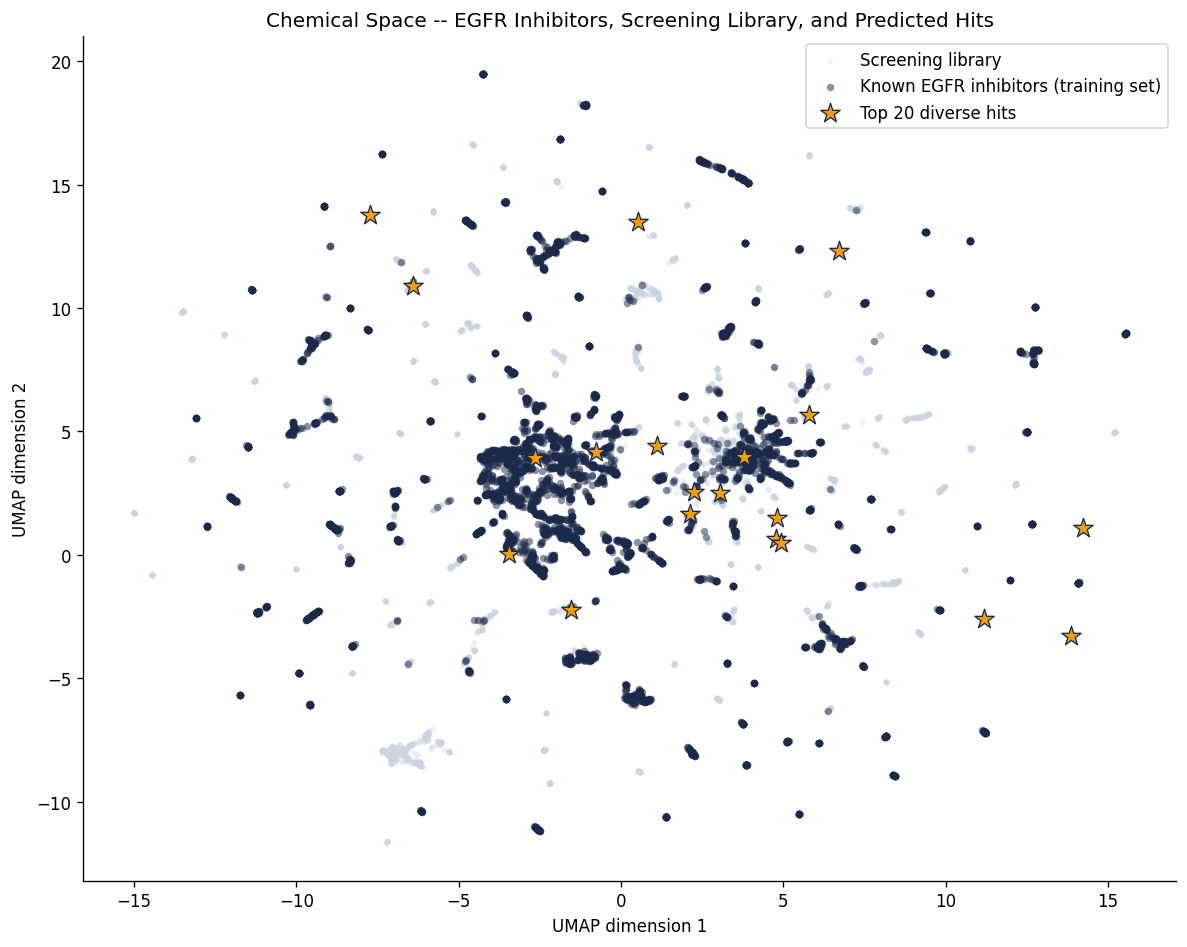


How to read this plot:
  Dark navy = known EGFR inhibitors from training set
  Gray = screening library compounds we scored
  Orange stars = our top 20 diverse predicted hits
  Stars near navy clusters = lower risk predictions
  Stars in isolated regions = potentially novel scaffolds, higher risk


In [ ]:
n_egfr = len(fp_egfr)
n_lib  = len(fp_lib)
n_hits = len(fp_hits)

emb_egfr = embedding[:n_egfr]
emb_lib  = embedding[n_egfr : n_egfr + n_lib]
emb_hits = embedding[n_egfr + n_lib :]

fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(emb_lib[:,0],  emb_lib[:,1],
           c='#CBD5E1', alpha=0.3, s=12, linewidths=0,
           label='Screening library')
ax.scatter(emb_egfr[:,0], emb_egfr[:,1],
           c='#1B2A4A', alpha=0.5, s=20, linewidths=0,
           label='Known EGFR inhibitors (training set)')
ax.scatter(emb_hits[:,0], emb_hits[:,1],
           c='#F59E0B', s=150, marker='*', zorder=5,
           edgecolors='#1B2A4A', linewidths=0.8,
           label='Top 20 diverse hits')

ax.set(xlabel='UMAP dimension 1', ylabel='UMAP dimension 2',
       title='Chemical Space -- EGFR Inhibitors, Screening Library, and Predicted Hits')
ax.legend(fontsize=10, loc='upper right')
plt.tight_layout()
plt.show()

print()
print('How to read this plot:')
print('  Dark navy = known EGFR inhibitors from training set')
print('  Gray = screening library compounds we scored')
print('  Orange stars = our top 20 diverse predicted hits')
print('  Stars near navy clusters = lower risk predictions')
print('  Stars in isolated regions = potentially novel scaffolds, higher risk')

In [ ]:
# Summary statistics for the top hits
print('Summary of top 20 diverse hits:')
print(f'  Predicted IC50 range: {df_display["pred_ic50_nM"].min():.1f} -- {df_display["pred_ic50_nM"].max():.1f} nM')
print(f'  Mean active probability: {df_display["pred_active_prob"].mean():.3f}')
#print(f'  MW range: {df_display["MW"].min():.0f} -- {df_display["MW"].max():.0f} Da')
#print(f'  LogP range: {df_display["LogP"].min():.2f} -- {df_display["LogP"].max():.2f}')
print(f'  Unique scaffolds: {df_display["scaffold"].nunique()} / 20')
print()
print('Source target breakdown:')
print(df_display['source_target'].value_counts().to_string())
print()
print('Next step in a real project: synthesize and test these compounds')
print('in an EGFR biochemical assay to validate the predictions.')

# Save results
df_display.to_csv(OUTPUT_DIR + 'top20_diverse_hits.csv', index=False)
df_lib.to_csv(OUTPUT_DIR + 'screening_library_scored.csv', index=False)
print()
print('Results saved to Drive.')

Summary of top 20 diverse hits:
  Predicted IC50 range: 15.8 -- 995.9 nM
  Mean active probability: 0.449
  Unique scaffolds: 20 / 20

Source target breakdown:
source_target
VEGFR2    10
ABL1       5
CDK2       3
BRAF       2

Next step in a real project: synthesize and test these compounds
in an EGFR biochemical assay to validate the predictions.

Results saved to Drive.


---
## Summary

In this notebook we ran a complete virtual screening campaign:

- **Loaded** the XGBoost QSAR model from Video 4b and verified predictions
- **Built** a library of ~7,000 kinase-focused compounds from ChEMBL
- **Deduplicated** to remove EGFR-tested compounds and invalid structures
- **Filtered** by Lipinski Ro5 to keep only drug-like compounds
- **Scored** every compound with XGBoost -- predicted log IC50 and activity probability
- **Selected** 20 diverse hits using MaxMin -- covering more scaffold space than naive top-20
- **Visualized** chemical space with UMAP -- showing where hits sit relative to known EGFR actives
- **Inspected** the top hits as 2D structures with predicted IC50 annotations

**Key lesson:** MaxMin diversity selection covered more unique scaffolds than naive
top-N selection for the same number of compounds. In a real campaign, this
translates to higher probability of finding at least one genuinely active scaffold.

**Caveats to mention in a real project:**
- These are predictions, not facts -- all hits need experimental validation
- The model has R2 of 0.62 -- predictions for novel scaffolds may be less accurate
- Lipinski Ro5 does not guarantee good ADMET properties, just oral bioavailability likelihood

**Next:** Video 6 -- High Content Analysis and Cell Painting